In [1]:
# To Get Class From Different Folders
import sys
import os
root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))

if root_path not in sys.path:
    sys.path.append(root_path)

In [2]:
import numpy as np
from mlp.layer import Linear
from mlp.activation import Tanh, Sigmoid, ReLU
from mlp.loss import SoftMaxCategoricalEntropy
from mlp.model import MLP
import sklearn
import matplotlib.pyplot as plt

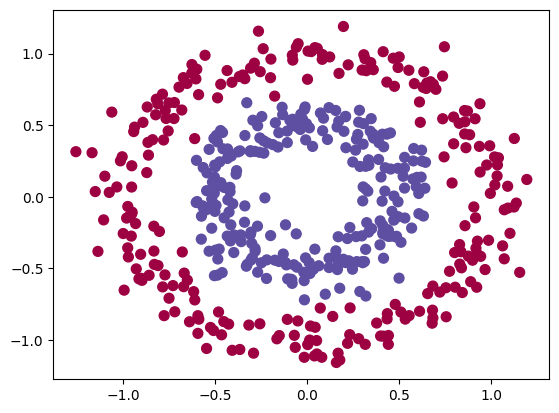

In [6]:
np.random.seed(0) #(Optional)
X,Y = sklearn.datasets.make_circles(n_samples=500, noise=0.1, factor=0.5)
plt.scatter(X[:,0], X[:,1], s=50, c=Y, cmap=plt.cm.Spectral)

In [21]:
# 1. Define the components
network_layers = [
    Linear(2, 6), Tanh(), 
    Linear(6, 3), Tanh(), 
    Linear(3, 2)
]
loss_criterion = SoftMaxCategoricalEntropy(temp=1.0)

model = MLP(network=network_layers, loss_function=loss_criterion, learning_rate=0.5)
model.fit(X, Y, epochs=500, batch_size=20, print_every=100)
test_accuracy = np.mean(model.predict(X) == Y)

epoch : 0 | loss : 0.7042025353062669 | accuracy : 0.508
epoch : 100 | loss : 0.00972267082753287 | accuracy : 0.996
epoch : 200 | loss : 0.007947994937911727 | accuracy : 0.996
epoch : 300 | loss : 0.003949217809527787 | accuracy : 0.998
epoch : 400 | loss : 0.0032108930986912854 | accuracy : 1.0
epoch : 500 | loss : 0.0016236433804945475 | accuracy : 1.0


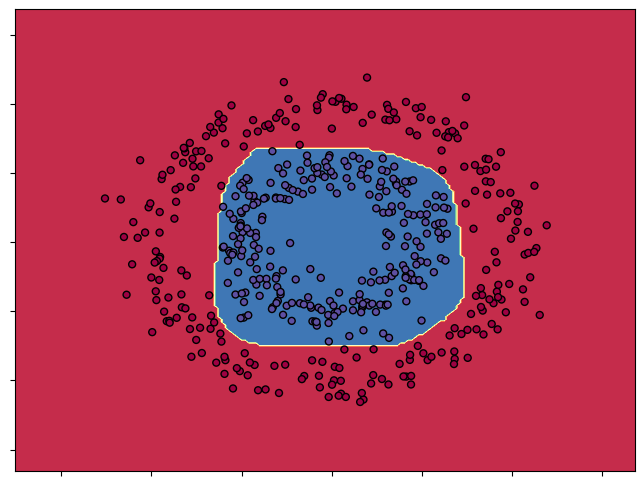

In [22]:
from utils.helper import plot_mlp_boundary
plot_mlp_boundary(X, Y, model)
